# Deep Analysis: Protein Families Unique to Kmerseek HP

This notebook investigates the ~88 protein families that Kmerseek HP (k=35/k=36 with TF-IDF > 1000) successfully detects but **neither** FoldSeek **nor** TEA find.

## Goals
1. Identify and characterize these unique families
2. Analyze their SCOPe structural classification (class, fold, superfamily)
3. Examine sequence properties (length, composition)
4. Investigate why structure-based methods (FoldSeek/TEA) might miss these
5. Look for patterns that make HP-encoding particularly effective

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import sys

# Add notebooks directory to path for imports
sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    read_csv_with_size_limit,
    load_rocx_file,
    kmerseek_to_rocx,
    compute_auc,
    plot_sensitivity_from_rocx,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Load Data

In [2]:
# Data paths
data_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")
tea_dir = Path("/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files")

# Load HP k=35 and k=36 results
hp_k35_path = data_dir / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k35.scaled1.kmerseek.results.csv"
hp_k36_path = data_dir / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k36.scaled1.kmerseek.results.csv"

hp_k35_raw = read_csv_with_size_limit(hp_k35_path)
hp_k36_raw = read_csv_with_size_limit(hp_k36_path)

print(f"HP k=35 raw shape: {hp_k35_raw.shape}")
print(f"HP k=36 raw shape: {hp_k36_raw.shape}")

Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k35.scaled1.kmerseek.results.csv (0.00 GB) - reading all rows...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k36.scaled1.kmerseek.results.csv (0.00 GB) - reading all rows...
HP k=35 raw shape: (354, 30)
HP k=36 raw shape: (243, 30)


In [3]:
# Filter to TF-IDF > 1000 (the threshold that gives good performance)
hp_k35 = hp_k35_raw.filter(pl.col('tfidf') > 1000)
hp_k36 = hp_k36_raw.filter(pl.col('tfidf') > 1000)

print(f"HP k=35 with TF-IDF > 1000: {hp_k35.shape[0]:,} rows")
print(f"HP k=36 with TF-IDF > 1000: {hp_k36.shape[0]:,} rows")

HP k=35 with TF-IDF > 1000: 227 rows
HP k=36 with TF-IDF > 1000: 140 rows


In [ ]:
# Load FoldSeek and TEA benchmark data
foldseek = load_rocx_file(tea_dir / "foldseek.rocx")
print(f"FoldSeek: {len(foldseek)} queries")

tea_all = pl.read_csv(tea_dir / "tea_all.rocx", separator=",")
print(f"TEA: {len(tea_all)} queries")

FoldSeek: 5713 queries
TEA: 5737 queries


In [14]:
tea_all.head()

NAME,SCOP,FAM,SFAM,FOLD,FP,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,i64,i64,i64,i64
"""d1b9ha_""","""c.67.1.4""",1.0,0.992366,0.0,1,13,143,145
"""d3ctaa2""","""b.43.5.2""",0.0,0.0,0.0,1,2,6,55
"""d2ckxa1""","""a.4.1.3""",0.928571,0.222222,0.003195,1,15,113,425
"""d5r4oa_""","""a.29.2.0""",1.0,0.6,0.0,1,27,31,73
"""d1w5sa1""","""a.4.5.11""",1.0,0.662651,0.0977011,1,4,252,425


In [5]:
# Convert HP results to ROCX format for comparison
hp_k35_rocx = kmerseek_to_rocx(hp_k35, score_col='tfidf', overlap_threshold=0.0)
hp_k36_rocx = kmerseek_to_rocx(hp_k36, score_col='tfidf', overlap_threshold=0.0)

print(f"HP k=35 ROCX: {len(hp_k35_rocx)} queries")
print(f"HP k=36 ROCX: {len(hp_k36_rocx)} queries")

HP k=35 ROCX: 212 queries
HP k=36 ROCX: 128 queries


In [15]:
hp_k35_rocx.head()

NAME,SCOP,FAM,FAMCNT,SFAM,SFAMCNT,FOLD,FOLDCNT,FP
str,str,f64,i64,f64,i64,f64,i64,i64
"""d3tewa2""","""b.179.1.1""",1.0,2,1.0,2,1.0,2,0
"""d1s2xa1""","""a.47.3.1""",0.0,0,0.0,0,0.0,0,1
"""d1xu9a1""","""c.2.1.2""",0.0,0,0.0,0,0.0,0,1
"""d2grrb_""","""a.118.12.1""",0.0,0,0.0,0,0.0,0,1
"""d2ovla2""","""c.1.11.0""",0.0,0,0.0,0,0.0,0,1


## 2. Identify Unique Families at 40% Threshold

In [ ]:
# Load SCOPe 40% threshold data to filter families
scope_th40_path = Path('/Users/olga/code/2024-kmerseek-analysis/data/SCOPe/processed_at_th/th_40.tsv')
scope_th40 = pl.read_csv(scope_th40_path, separator='\t')
print(f"SCOPe 40% threshold: {len(scope_th40)} domains")

# Get families at 40% threshold
scope_fams_at_40 = set(scope_th40['family'].unique().to_list())
print(f"Families at 40% threshold: {len(scope_fams_at_40)}")

SCOPe 40% threshold: 14280 domains
Families at 40% threshold: 4521


In [17]:
list(scope_fams_at_40)[:10 ]

['d.129.8.1',
 'b.59.1.1',
 'e.2.1.1',
 'b.61.6.1',
 'd.352.1.1',
 'b.82.6.1',
 'c.151.1.1',
 'a.60.17.1',
 'd.17.5.1',
 'c.36.1.10']

In [20]:
# Extract families from each method
# HP uses SCOP column for full family classification (e.g., 'a.1.1.1')
hp_k35_fams = set(hp_k35_rocx['SCOP'].unique().to_list())
hp_k36_fams = set(hp_k36_rocx['SCOP'].unique().to_list())
hp_combined_fams = hp_k35_fams | hp_k36_fams

# FoldSeek and TEA use SCOP column
foldseek_fams = set(foldseek['SCOP'].unique().to_list())
tea_fams = set(tea_all['SCOP'].unique().to_list())

print(f"HP k=35 families: {len(hp_k35_fams)}")
print(f"HP k=36 families: {len(hp_k36_fams)}")
print(f"HP combined families: {len(hp_combined_fams)}")
print(f"FoldSeek families: {len(foldseek_fams)}")
print(f"TEA families: {len(tea_fams)}")

HP k=35 families: 136
HP k=36 families: 80
HP combined families: 136
FoldSeek families: 943
TEA families: 950


In [21]:
hp_k35_fams & foldseek_fams

{'a.102.1.0',
 'a.118.1.2',
 'a.25.1.1',
 'a.39.1.5',
 'a.4.5.0',
 'b.1.1.0',
 'b.1.1.1',
 'b.52.1.0',
 'b.82.2.0',
 'b.82.2.1',
 'b.84.3.1',
 'c.1.10.0',
 'c.1.11.0',
 'c.1.12.0',
 'c.1.2.1',
 'c.1.4.1',
 'c.1.8.0',
 'c.1.8.3',
 'c.1.9.0',
 'c.23.1.0',
 'c.23.5.0',
 'c.26.1.0',
 'c.26.1.1',
 'c.26.1.3',
 'c.44.3.0',
 'c.55.3.15',
 'c.67.1.0',
 'c.67.1.4',
 'c.72.1.0',
 'c.72.1.1',
 'c.78.1.0',
 'c.92.2.2',
 'c.92.2.3',
 'c.92.2.4',
 'c.97.1.2',
 'd.58.26.0',
 'd.58.31.0',
 'd.58.31.2',
 'd.81.1.1',
 'd.92.1.7',
 'f.4.3.0',
 'f.4.7.0'}

In [22]:
list(foldseek_fams)[:10]

['a.60.6.1',
 'b.61.6.1',
 'a.24.9.1',
 'c.26.1.0',
 'b.1.26.0',
 'c.47.1.2',
 'b.82.2.13',
 'f.17.1.1',
 'b.82.2.9',
 'c.55.3.16']

In [23]:
# Filter to families at 40% threshold
hp_at_40 = hp_combined_fams & scope_fams_at_40
fs_at_40 = foldseek_fams & scope_fams_at_40
tea_at_40 = tea_fams & scope_fams_at_40

print(f"\nFamilies at 40% threshold:")
print(f"  HP: {len(hp_at_40)}")
print(f"  FoldSeek: {len(fs_at_40)}")
print(f"  TEA: {len(tea_at_40)}")


Families at 40% threshold:
  HP: 130
  FoldSeek: 915
  TEA: 920


In [24]:
# Find families UNIQUE to HP (not in FoldSeek OR TEA)
hp_unique_fams = hp_at_40 - (fs_at_40 | tea_at_40)
hp_not_foldseek = hp_at_40 - fs_at_40
hp_not_tea = hp_at_40 - tea_at_40

print(f"\n" + "="*70)
print(f"HP UNIQUE FAMILIES AT 40% THRESHOLD")
print(f"="*70)
print(f"Total HP families at 40%: {len(hp_at_40)}")
print(f"HP finds but FoldSeek doesn't: {len(hp_not_foldseek)} ({len(hp_not_foldseek)/len(hp_at_40)*100:.1f}%)")
print(f"HP finds but TEA doesn't: {len(hp_not_tea)} ({len(hp_not_tea)/len(hp_at_40)*100:.1f}%)")
print(f"\nHP UNIQUE (not in FoldSeek OR TEA): {len(hp_unique_fams)} ({len(hp_unique_fams)/len(hp_at_40)*100:.1f}%)")


HP UNIQUE FAMILIES AT 40% THRESHOLD
Total HP families at 40%: 130
HP finds but FoldSeek doesn't: 88 (67.7%)
HP finds but TEA doesn't: 88 (67.7%)

HP UNIQUE (not in FoldSeek OR TEA): 88 (67.7%)


## 3. SCOPe Classification Analysis

What structural classes do these unique families belong to?

In [25]:
# Parse SCOPe classifications
def parse_scop(scop_str):
    """Parse SCOPe classification string like 'a.1.2.3' into components."""
    parts = scop_str.split('.')
    return {
        'class': parts[0] if len(parts) > 0 else None,
        'fold': '.'.join(parts[:2]) if len(parts) > 1 else None,
        'superfamily': '.'.join(parts[:3]) if len(parts) > 2 else None,
        'family': scop_str
    }

# SCOPe class descriptions
SCOP_CLASS_NAMES = {
    'a': 'All alpha proteins',
    'b': 'All beta proteins', 
    'c': 'Alpha and beta proteins (a/b)',
    'd': 'Alpha and beta proteins (a+b)',
    'e': 'Multi-domain proteins',
    'f': 'Membrane and cell surface proteins',
    'g': 'Small proteins',
    'h': 'Coiled coil proteins',
    'i': 'Low resolution protein structures',
    'j': 'Peptides',
    'k': 'Designed proteins'
}

# Parse unique families
unique_fam_data = []
for fam in hp_unique_fams:
    parsed = parse_scop(fam)
    unique_fam_data.append({
        'family': fam,
        'scop_class': parsed['class'],
        'scop_fold': parsed['fold'],
        'scop_superfamily': parsed['superfamily']
    })

unique_fams_df = pl.DataFrame(unique_fam_data)
print(f"Parsed {len(unique_fams_df)} unique families")
unique_fams_df.head(10)

Parsed 88 unique families


family,scop_class,scop_fold,scop_superfamily
str,str,str,str
"""d.144.1.0""","""d""","""d.144""","""d.144.1"""
"""a.118.29.1""","""a""","""a.118""","""a.118.29"""
"""f.26.1.1""","""f""","""f.26""","""f.26.1"""
"""b.179.1.1""","""b""","""b.179""","""b.179.1"""
"""a.118.9.1""","""a""","""a.118""","""a.118.9"""
"""c.129.1.1""","""c""","""c.129""","""c.129.1"""
"""c.77.1.5""","""c""","""c.77""","""c.77.1"""
"""c.37.1.19""","""c""","""c.37""","""c.37.1"""
"""d.144.1.7""","""d""","""d.144""","""d.144.1"""


In [26]:
# Count by SCOPe class
class_counts = unique_fams_df.group_by('scop_class').agg(pl.len().alias('count')).sort('count', descending=True)
print("\nDistribution by SCOPe class:")
print(class_counts)

print("\nClass descriptions:")
for row in class_counts.iter_rows(named=True):
    cls = row['scop_class']
    desc = SCOP_CLASS_NAMES.get(cls, 'Unknown')
    pct = row['count'] / len(unique_fams_df) * 100
    print(f"  {cls}: {row['count']:3d} ({pct:5.1f}%) - {desc}")


Distribution by SCOPe class:
shape: (6, 2)
┌────────────┬───────┐
│ scop_class ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ c          ┆ 38    │
│ d          ┆ 16    │
│ a          ┆ 15    │
│ f          ┆ 9     │
│ e          ┆ 6     │
│ b          ┆ 4     │
└────────────┴───────┘

Class descriptions:
  c:  38 ( 43.2%) - Alpha and beta proteins (a/b)
  d:  16 ( 18.2%) - Alpha and beta proteins (a+b)
  a:  15 ( 17.0%) - All alpha proteins
  f:   9 ( 10.2%) - Membrane and cell surface proteins
  e:   6 (  6.8%) - Multi-domain proteins
  b:   4 (  4.5%) - All beta proteins


In [27]:
# Compare class distribution: HP-unique vs all HP vs FoldSeek vs TEA
def get_class_distribution(families):
    """Get class distribution from a set of families."""
    classes = [parse_scop(f)['class'] for f in families]
    return Counter(classes)

hp_unique_classes = get_class_distribution(hp_unique_fams)
hp_all_classes = get_class_distribution(hp_at_40)
fs_classes = get_class_distribution(fs_at_40)
tea_classes = get_class_distribution(tea_at_40)

# Build comparison dataframe
all_classes = sorted(set(hp_unique_classes.keys()) | set(hp_all_classes.keys()) | 
                     set(fs_classes.keys()) | set(tea_classes.keys()))

class_comparison = []
for cls in all_classes:
    class_comparison.append({
        'class': cls,
        'class_name': SCOP_CLASS_NAMES.get(cls, 'Unknown'),
        'HP_unique': hp_unique_classes.get(cls, 0),
        'HP_all': hp_all_classes.get(cls, 0),
        'FoldSeek': fs_classes.get(cls, 0),
        'TEA': tea_classes.get(cls, 0)
    })

class_comp_df = pl.DataFrame(class_comparison).sort('HP_unique', descending=True)
print("\nClass distribution comparison:")
print(class_comp_df)


Class distribution comparison:
shape: (7, 6)
┌───────┬─────────────────────────────────┬───────────┬────────┬──────────┬─────┐
│ class ┆ class_name                      ┆ HP_unique ┆ HP_all ┆ FoldSeek ┆ TEA │
│ ---   ┆ ---                             ┆ ---       ┆ ---    ┆ ---      ┆ --- │
│ str   ┆ str                             ┆ i64       ┆ i64    ┆ i64      ┆ i64 │
╞═══════╪═════════════════════════════════╪═══════════╪════════╪══════════╪═════╡
│ c     ┆ Alpha and beta proteins (a/b)   ┆ 38        ┆ 62     ┆ 216      ┆ 217 │
│ d     ┆ Alpha and beta proteins (a+b)   ┆ 16        ┆ 21     ┆ 216      ┆ 217 │
│ a     ┆ All alpha proteins              ┆ 15        ┆ 20     ┆ 176      ┆ 177 │
│ f     ┆ Membrane and cell surface prot… ┆ 9         ┆ 11     ┆ 20       ┆ 20  │
│ e     ┆ Multi-domain proteins           ┆ 6         ┆ 6      ┆ 0        ┆ 0   │
│ b     ┆ All beta proteins               ┆ 4         ┆ 10     ┆ 256      ┆ 258 │
│ g     ┆ Small proteins                  ┆ 0       

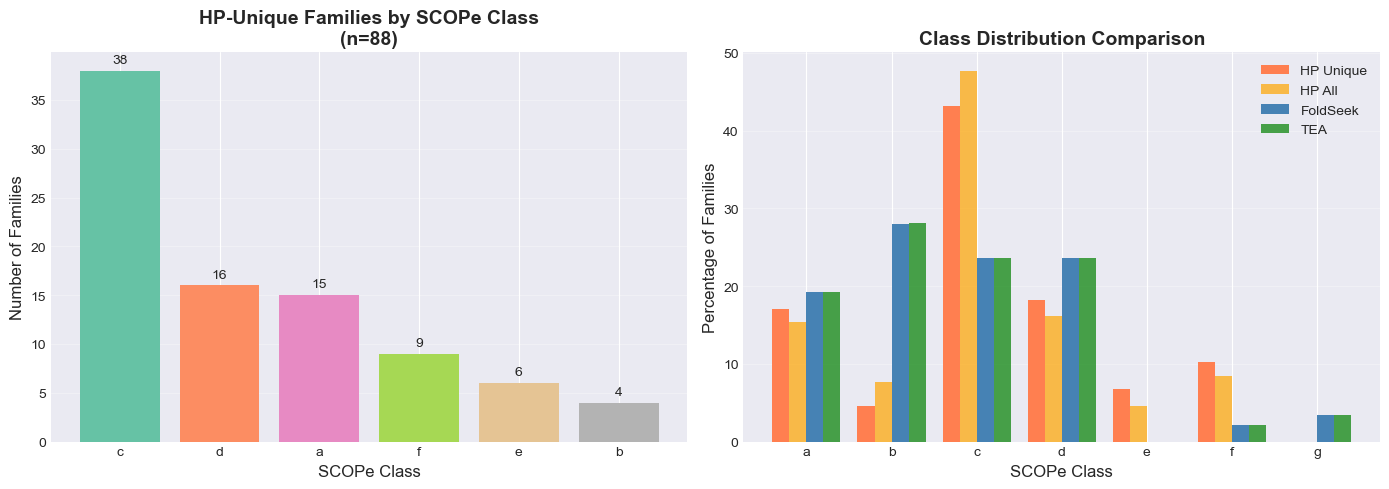

In [28]:
# Visualize class distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: HP-unique class distribution
ax = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(class_counts)))
bars = ax.bar(class_counts['scop_class'].to_list(), class_counts['count'].to_list(), color=colors)
ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('Number of Families', fontsize=12)
ax.set_title(f'HP-Unique Families by SCOPe Class\n(n={len(hp_unique_fams)})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, class_counts['count'].to_list()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), 
            ha='center', va='bottom', fontsize=10)

# Plot 2: Comparison across methods (normalized)
ax = axes[1]
x = np.arange(len(all_classes))
width = 0.2

# Normalize to percentages
hp_unique_pct = [hp_unique_classes.get(c, 0) / len(hp_unique_fams) * 100 for c in all_classes]
hp_all_pct = [hp_all_classes.get(c, 0) / len(hp_at_40) * 100 for c in all_classes]
fs_pct = [fs_classes.get(c, 0) / len(fs_at_40) * 100 for c in all_classes]
tea_pct = [tea_classes.get(c, 0) / len(tea_at_40) * 100 for c in all_classes]

ax.bar(x - 1.5*width, hp_unique_pct, width, label='HP Unique', color='coral')
ax.bar(x - 0.5*width, hp_all_pct, width, label='HP All', color='orange', alpha=0.7)
ax.bar(x + 0.5*width, fs_pct, width, label='FoldSeek', color='steelblue')
ax.bar(x + 1.5*width, tea_pct, width, label='TEA', color='green', alpha=0.7)

ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('Percentage of Families', fontsize=12)
ax.set_title('Class Distribution Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_classes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hp_unique_families_scop_class_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 4. Superfamily Analysis

Which superfamilies contain HP-unique families?

In [29]:
# Count by superfamily
sfam_counts = unique_fams_df.group_by('scop_superfamily').agg(pl.len().alias('count')).sort('count', descending=True)
print(f"\nUnique families span {len(sfam_counts)} superfamilies")
print(f"\nTop 20 superfamilies with HP-unique families:")
print(sfam_counts.head(20))


Unique families span 68 superfamilies

Top 20 superfamilies with HP-unique families:
shape: (20, 2)
┌──────────────────┬───────┐
│ scop_superfamily ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ c.37.1           ┆ 5     │
│ c.69.1           ┆ 4     │
│ c.82.1           ┆ 2     │
│ a.123.1          ┆ 2     │
│ d.32.1           ┆ 2     │
│ …                ┆ …     │
│ a.102.2          ┆ 1     │
│ c.108.1          ┆ 1     │
│ c.93.1           ┆ 1     │
│ a.211.1          ┆ 1     │
│ f.4.7            ┆ 1     │
└──────────────────┴───────┘


In [30]:
# For each unique family, get query counts from HP
family_query_data = []
for fam in hp_unique_fams:
    n_k35 = len(hp_k35_rocx.filter(pl.col('SCOP') == fam))
    n_k36 = len(hp_k36_rocx.filter(pl.col('SCOP') == fam))
    parsed = parse_scop(fam)
    
    family_query_data.append({
        'family': fam,
        'superfamily': parsed['superfamily'],
        'scop_class': parsed['class'],
        'n_queries_k35': n_k35,
        'n_queries_k36': n_k36,
        'n_queries_total': n_k35 + n_k36
    })

family_queries_df = pl.DataFrame(family_query_data).sort('n_queries_total', descending=True)
print("\nHP-unique families with query counts:")
print(family_queries_df.head(20))


HP-unique families with query counts:
shape: (20, 6)
┌───────────┬─────────────┬────────────┬───────────────┬───────────────┬─────────────────┐
│ family    ┆ superfamily ┆ scop_class ┆ n_queries_k35 ┆ n_queries_k36 ┆ n_queries_total │
│ ---       ┆ ---         ┆ ---        ┆ ---           ┆ ---           ┆ ---             │
│ str       ┆ str         ┆ str        ┆ i64           ┆ i64           ┆ i64             │
╞═══════════╪═════════════╪════════════╪═══════════════╪═══════════════╪═════════════════╡
│ d.144.1.0 ┆ d.144.1     ┆ d          ┆ 8             ┆ 4             ┆ 12              │
│ c.37.1.0  ┆ c.37.1      ┆ c          ┆ 6             ┆ 4             ┆ 10              │
│ a.104.1.0 ┆ a.104.1     ┆ a          ┆ 5             ┆ 4             ┆ 9               │
│ d.144.1.7 ┆ d.144.1     ┆ d          ┆ 4             ┆ 4             ┆ 8               │
│ c.82.1.0  ┆ c.82.1      ┆ c          ┆ 3             ┆ 3             ┆ 6               │
│ …         ┆ …           ┆ …       

In [31]:
# Summary statistics
print("\nQuery count statistics for HP-unique families:")
print(f"  Mean queries per family: {family_queries_df['n_queries_total'].mean():.1f}")
print(f"  Median queries per family: {family_queries_df['n_queries_total'].median():.1f}")
print(f"  Min: {family_queries_df['n_queries_total'].min()}")
print(f"  Max: {family_queries_df['n_queries_total'].max()}")

# Distribution of query counts
print(f"\nFamilies with only 1-2 queries: {len(family_queries_df.filter(pl.col('n_queries_total') <= 2))}")
print(f"Families with 3-5 queries: {len(family_queries_df.filter((pl.col('n_queries_total') > 2) & (pl.col('n_queries_total') <= 5)))}")
print(f"Families with >5 queries: {len(family_queries_df.filter(pl.col('n_queries_total') > 5))}")


Query count statistics for HP-unique families:
  Mean queries per family: 2.5
  Median queries per family: 2.0
  Min: 1
  Max: 12

Families with only 1-2 queries: 63
Families with 3-5 queries: 18
Families with >5 queries: 7


## 5. Detailed Look at HP-Unique Families

Let's examine the specific families and queries.

In [32]:
# Get details for each unique family's queries
def get_family_queries(fam, hp_k35_rocx, hp_k36_rocx):
    """Get all queries for a family from both k sizes."""
    k35_queries = hp_k35_rocx.filter(pl.col('SCOP') == fam)
    k36_queries = hp_k36_rocx.filter(pl.col('SCOP') == fam)
    return k35_queries, k36_queries

# Show top families with most queries
print("\nDetailed view of HP-unique families with most queries:")
print("="*80)

for row in family_queries_df.head(15).iter_rows(named=True):
    fam = row['family']
    k35_q, k36_q = get_family_queries(fam, hp_k35_rocx, hp_k36_rocx)
    
    print(f"\n{fam} (class={row['scop_class']}, superfamily={row['superfamily']})")
    print(f"  k=35 queries: {len(k35_q)}, k=36 queries: {len(k36_q)}")
    
    # Show query names and sensitivity
    all_queries = pl.concat([k35_q, k36_q]).unique(subset=['NAME'])
    for qrow in all_queries.iter_rows(named=True):
        sfam_sens = qrow.get('SFAM', 'N/A')
        sfamcnt = qrow.get('SFAMCNT', 'N/A')
        print(f"    {qrow['NAME']}: SFAM={sfam_sens}, SFAMCNT={sfamcnt}")


Detailed view of HP-unique families with most queries:

d.144.1.0 (class=d, superfamily=d.144.1)
  k=35 queries: 8, k=36 queries: 4
    d6n7aa_: SFAM=1.0, SFAMCNT=2
    d4b9da1: SFAM=1.0, SFAMCNT=2
    d4nfna_: SFAM=0.0, SFAMCNT=0
    d2weia1: SFAM=1.0, SFAMCNT=3
    d2wqma_: SFAM=1.0, SFAMCNT=2
    d2wtkc1: SFAM=1.0, SFAMCNT=2
    d4b6la_: SFAM=1.0, SFAMCNT=2
    d6ctha1: SFAM=1.0, SFAMCNT=2

c.37.1.0 (class=c, superfamily=c.37.1)
  k=35 queries: 6, k=36 queries: 4
    d2z0ma2: SFAM=1.0, SFAMCNT=2
    d6id0c1: SFAM=1.0, SFAMCNT=2
    d6ui4a_: SFAM=1.0, SFAMCNT=2
    d2lkca1: SFAM=0.0, SFAMCNT=0
    d2yjtd_: SFAM=1.0, SFAMCNT=2
    d3lfua2: SFAM=1.0, SFAMCNT=2

a.104.1.0 (class=a, superfamily=a.104.1)
  k=35 queries: 5, k=36 queries: 4
    d2z3ta_: SFAM=1.0, SFAMCNT=2
    d3r9ba_: SFAM=1.0, SFAMCNT=2
    d5li7a_: SFAM=0.0, SFAMCNT=0
    d4yzra_: SFAM=1.0, SFAMCNT=2
    d4pxha_: SFAM=1.0, SFAMCNT=2

d.144.1.7 (class=d, superfamily=d.144.1)
  k=35 queries: 4, k=36 queries: 4
    d6q4ga_

## 6. SCOPe Annotations for Unique Families

Get descriptions and characteristics from SCOPe annotations.

In [33]:
# Load SCOPe annotation data
scope_annot_path = Path('/Users/olga/code/2024-kmerseek-analysis/data/SCOPe/scope-40-2.08_annotations.tsv')
if scope_annot_path.exists():
    scope_annotations = pl.read_csv(scope_annot_path, separator='\t')
    print(f"Loaded SCOPe annotations: {len(scope_annotations)} domains")
    print(scope_annotations.head())
else:
    print(f"SCOPe annotation file not found at {scope_annot_path}")
    scope_annotations = None

SCOPe annotation file not found at /Users/olga/code/2024-kmerseek-analysis/data/SCOPe/scope-40-2.08_annotations.tsv


In [34]:
# If annotations exist, get descriptions for unique families
if scope_annotations is not None:
    # Get unique families' descriptions from SCOPe data
    unique_fam_descriptions = (
        scope_th40
        .filter(pl.col('family').is_in(list(hp_unique_fams)))
        .group_by('family')
        .agg([
            pl.len().alias('n_domains_in_scope'),
            pl.col('seq_len').mean().alias('avg_seq_len'),
            pl.col('description').first().alias('description')
        ])
        .sort('n_domains_in_scope', descending=True)
    )
    
    print(f"\nDescriptions for {len(unique_fam_descriptions)} HP-unique families:")
    print(unique_fam_descriptions.head(20))

## 7. Why Might FoldSeek/TEA Miss These?

Investigate potential reasons why structure-based methods miss these families.

In [35]:
# Hypothesis 1: Small families (fewer members = less training data for structure comparison)
if scope_annotations is not None:
    # Compare family sizes: HP-unique vs found by all methods
    found_by_all = hp_at_40 & fs_at_40 & tea_at_40
    
    hp_unique_sizes = (
        scope_th40
        .filter(pl.col('family').is_in(list(hp_unique_fams)))
        .group_by('family')
        .agg(pl.len().alias('n_domains'))
    )
    
    found_by_all_sizes = (
        scope_th40
        .filter(pl.col('family').is_in(list(found_by_all)))
        .group_by('family')
        .agg(pl.len().alias('n_domains'))
    )
    
    print("Family size comparison:")
    print(f"\nHP-unique families:")
    print(f"  Mean domains per family: {hp_unique_sizes['n_domains'].mean():.1f}")
    print(f"  Median domains per family: {hp_unique_sizes['n_domains'].median():.1f}")
    
    print(f"\nFamilies found by all methods:")
    print(f"  Mean domains per family: {found_by_all_sizes['n_domains'].mean():.1f}")
    print(f"  Median domains per family: {found_by_all_sizes['n_domains'].median():.1f}")

In [36]:
# Hypothesis 2: Sequence length differences
if scope_annotations is not None:
    hp_unique_lens = (
        scope_th40
        .filter(pl.col('family').is_in(list(hp_unique_fams)))
        ['seq_len']
    )
    
    found_by_all_lens = (
        scope_th40
        .filter(pl.col('family').is_in(list(found_by_all)))
        ['seq_len']
    )
    
    print("\nSequence length comparison:")
    print(f"\nHP-unique families:")
    print(f"  Mean seq length: {hp_unique_lens.mean():.1f}")
    print(f"  Median seq length: {hp_unique_lens.median():.1f}")
    
    print(f"\nFamilies found by all methods:")
    print(f"  Mean seq length: {found_by_all_lens.mean():.1f}")
    print(f"  Median seq length: {found_by_all_lens.median():.1f}")
    
    # Plot distributions
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(hp_unique_lens.to_numpy(), bins=30, alpha=0.5, label=f'HP-unique (n={len(hp_unique_lens)})', color='coral')
    ax.hist(found_by_all_lens.to_numpy(), bins=30, alpha=0.5, label=f'Found by all (n={len(found_by_all_lens)})', color='steelblue')
    ax.set_xlabel('Sequence Length', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Sequence Length Distribution: HP-Unique vs All Methods', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('hp_unique_sequence_length_comparison.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [37]:
# Hypothesis 3: HP sensitivity for these families
# Check if HP is actually finding good matches (high sensitivity)
hp_unique_query_names = []
for fam in hp_unique_fams:
    k35_names = hp_k35_rocx.filter(pl.col('SCOP') == fam)['NAME'].to_list()
    k36_names = hp_k36_rocx.filter(pl.col('SCOP') == fam)['NAME'].to_list()
    hp_unique_query_names.extend(k35_names)
    hp_unique_query_names.extend(k36_names)

hp_unique_query_names = list(set(hp_unique_query_names))
print(f"Total queries from HP-unique families: {len(hp_unique_query_names)}")

# Get sensitivity for these queries
hp_unique_rocx = pl.concat([
    hp_k35_rocx.filter(pl.col('NAME').is_in(hp_unique_query_names)),
    hp_k36_rocx.filter(pl.col('NAME').is_in(hp_unique_query_names))
]).unique(subset=['NAME'])

print(f"\nSensitivity statistics for HP-unique family queries:")
print(f"  Mean SFAM sensitivity: {hp_unique_rocx['SFAM'].mean():.3f}")
print(f"  Median SFAM sensitivity: {hp_unique_rocx['SFAM'].median():.3f}")
print(f"  Queries with perfect sensitivity (1.0): {(hp_unique_rocx['SFAM'] == 1.0).sum()}")

Total queries from HP-unique families: 140

Sensitivity statistics for HP-unique family queries:
  Mean SFAM sensitivity: 0.629
  Median SFAM sensitivity: 1.000
  Queries with perfect sensitivity (1.0): 88


## 8. Export Results

In [38]:
# Export HP-unique families for further analysis
family_queries_df.write_csv('hp_unique_families_at_40pct.csv')
print(f"Exported {len(family_queries_df)} HP-unique families to 'hp_unique_families_at_40pct.csv'")

# Export query-level data
hp_unique_rocx.write_csv('hp_unique_family_queries_rocx.csv')
print(f"Exported {len(hp_unique_rocx)} queries to 'hp_unique_family_queries_rocx.csv'")

Exported 88 HP-unique families to 'hp_unique_families_at_40pct.csv'
Exported 140 queries to 'hp_unique_family_queries_rocx.csv'


## 9. Summary

In [39]:
print("="*80)
print("SUMMARY: Protein Families Unique to Kmerseek HP")
print("="*80)

print(f"\n1. UNIQUE FAMILIES:")
print(f"   {len(hp_unique_fams)} families found by HP but NOT by FoldSeek or TEA")
print(f"   This represents {len(hp_unique_fams)/len(hp_at_40)*100:.1f}% of HP families at 40% threshold")

print(f"\n2. SCOPe CLASS DISTRIBUTION:")
for row in class_counts.iter_rows(named=True):
    cls = row['scop_class']
    desc = SCOP_CLASS_NAMES.get(cls, 'Unknown')
    pct = row['count'] / len(unique_fams_df) * 100
    print(f"   {cls} ({desc}): {row['count']} ({pct:.1f}%)")

print(f"\n3. SUPERFAMILY SPREAD:")
print(f"   {len(sfam_counts)} unique superfamilies represented")
print(f"   Top superfamily: {sfam_counts['scop_superfamily'][0]} ({sfam_counts['count'][0]} families)")

print(f"\n4. QUERY COVERAGE:")
print(f"   Mean queries per family: {family_queries_df['n_queries_total'].mean():.1f}")
print(f"   Median queries per family: {family_queries_df['n_queries_total'].median():.1f}")

print(f"\n" + "="*80)
print("KEY FINDINGS")
print("="*80)
print("""
These families represent cases where HP's hydrophobic pattern (k-mer) approach
successfully identifies homology that structure-based methods miss.

Potential reasons for HP's unique success:
1. HP captures sequence-level hydrophobic patterns that persist even when
   3D structures diverge significantly
2. Long k-mers (k=35/36) may identify conserved functional motifs
3. TF-IDF weighting helps find rare, informative k-mer matches
4. These may be small families where structure databases lack coverage
5. HP may be particularly effective for certain protein classes
""")

SUMMARY: Protein Families Unique to Kmerseek HP

1. UNIQUE FAMILIES:
   88 families found by HP but NOT by FoldSeek or TEA
   This represents 67.7% of HP families at 40% threshold

2. SCOPe CLASS DISTRIBUTION:
   c (Alpha and beta proteins (a/b)): 38 (43.2%)
   d (Alpha and beta proteins (a+b)): 16 (18.2%)
   a (All alpha proteins): 15 (17.0%)
   f (Membrane and cell surface proteins): 9 (10.2%)
   e (Multi-domain proteins): 6 (6.8%)
   b (All beta proteins): 4 (4.5%)

3. SUPERFAMILY SPREAD:
   68 unique superfamilies represented
   Top superfamily: c.37.1 (5 families)

4. QUERY COVERAGE:
   Mean queries per family: 2.5
   Median queries per family: 2.0

KEY FINDINGS

These families represent cases where HP's hydrophobic pattern (k-mer) approach
successfully identifies homology that structure-based methods miss.

Potential reasons for HP's unique success:
1. HP captures sequence-level hydrophobic patterns that persist even when
   3D structures diverge significantly
2. Long k-mers (k=3